In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

# Load librairies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob

import ArcTools as Atools


# Few useful functions

In [3]:
def conv_platform(fld):
    if fld=='S':
        pf_code=0
    elif fld=='I':
        pf_code=1
    elif fld=='A':
        pf_code=2
    elif fld=='F':
        pf_code=3
    elif fld=='SU':
        pf_code=4
    elif fld=='C':
        pf_code=5
    elif fld=='CO':
        pf_code=6
    else:
        pf_code=9
        
    return pf_code

In [4]:
def conv_date(fld):
    y = int(fld[:4])
    m = int(fld[5:7])
    d = int(fld[8:10])
    h = int(fld[11:13])
    mi = int(fld[14:16])
    #print(fld)
    if h == 99:
        h = 0
        mi=0
    if d == 0:
        d = 1
        
    return dt.datetime(y,m,d,h,mi,0).toordinal()

In [5]:
def interp_prof(x_old, y_old, x_new):

    from scipy.interpolate import Akima1DInterpolator
    inans_y = ~np.isnan(y_old)
    inans_x = ~np.isnan(x_old)
    inans = inans_y*inans_x
    if np.any(inans):
        if len(y_old[inans])>1:

            spl = Akima1DInterpolator(x_old[inans], y_old[inans])
            y_new = spl(x_new)
        else:
            y_new = []
    else:
        y_new = []
    
    return y_new

In [6]:
def concat_netcdf(file_list):
    ds = xr.open_dataset(file_list[0])
    param = ds.salinity.data
    lon = ds.longitude.data
    lat = ds.latitude.data
    time = ds.time.data
    depth = ds.depth.data
    
    for f in file_list[1:]:
        ds = xr.open_dataset(f)
        param = np.concatenate((param, ds.salinity.data),axis=0)
        lon = np.concatenate((lon, ds.longitude.data),axis=0)
        lat = np.concatenate((lat, ds.latitude.data),axis=0)
        time = np.concatenate((time, ds.time.data),axis=0)
        
    return param,lon,lat,time,depth

# Load ISAS vertical grid

In [7]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data

# Loop through the udash .txt files

Behrendt, A., Sumata, H., Rabe, B., and Schauer, U.: UDASH – Unified Database for Arctic and Subarctic Hydrography, Earth Syst. Sci. Data, 10, 1119–1138, https://doi.org/10.5194/essd-10-1119-2018, 2018.

- 0 Prof_no
- 1 Cruise
- 2 Station
- 3 Platform
- 4 Type
- 5 yyyy-mm-ddThh:mm
- 6 Longitude_[deg]
- 7 Latitude_[deg]
- 8 Pressure_[dbar]
- 9 Depth_[m]
- 10 QF
- 11 Temp_[°C]
- 12 QF
- 13 Salinity_[psu]
- 14 QF
- 15 Source
- 16 DOI
- 17 WOD-Cruise-ID
- 18 WOD-Cast-ID

S: ships, I: ice tethered, A: helicopters/airplanes, F: profiling floats, SU: submarines, C: ice camps, CO: coastal station, NA: unknown.
Instrument abbreviations. CTD: conductivity–temperature–depth, XCTD: expendable CTD, B: bottle, STD: salinity–temperature–depth, XBT: expendable
bathythermograph, MBT: mechanical bathythermograph, DBT: digital bathythermograph.

In [8]:
# read udash in situ data
udash_path = '/data0/user/aprigent/UDASH/'
list_udash = np.sort(glob.glob(udash_path + '*txt'))
list_udash

array(['/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1980.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1981.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1982.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1983.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1984.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1985.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1986.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1987.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1988.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1989.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1990.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1991.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1992.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1993.txt',
       '/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1994.t

In [9]:
for f in list_udash:
    number_of_excluded_profiles = 0
    number_of_wrong_DATES = 0

    print(f)
    fid = open(f)
    no_udash = []
    pf_udash = []
    lon_udash = []
    lat_udash = []
    date_udash = []
    pres_udash = []
    dep_udash = []
    temp_udash = []
    psal_udash = []
    source_udash = []
    
    # read UDASH format
    udash = fid.readlines()
    for l in udash[1:]:
        

        no_udash.append(int(l.split()[0]))
        pf_udash.append(l.split()[3])
        lon_udash.append(float(l.split()[6]))
        lat_udash.append(float(l.split()[7]))
        date_udash.append(l.split()[5])
        pres_udash.append(float(l.split()[8]))
        dep_udash.append(float(l.split()[9]))
        temp_udash.append(float(l.split()[11]))
        psal_udash.append(float(l.split()[13]))
        source_udash.append(l.split()[15])

    date_ord = []
    valid_indices = []  # Track which indices have valid dates
    
    for i, d in enumerate(date_udash):
        ytime = int(d[0:4])
        mtime = int(d[5:7])
        dtime = int(d[8:10])
        if dtime == 0:
            print('day =00')
            number_of_wrong_DATES += 1
            continue
        
        date_ord.append(dt.datetime(ytime, mtime, dtime).toordinal())
        valid_indices.append(i)


    # Filter all arrays to only include valid date indices
    valid_indices = np.array(valid_indices)
    no_udash = np.array(no_udash)[valid_indices]
    lon_udash = np.array(lon_udash)[valid_indices]
    lat_udash = np.array(lat_udash)[valid_indices]
    date_udash = np.array(date_udash)[valid_indices]
    psal_udash = np.array(psal_udash)[valid_indices]
    temp_udash = np.array(temp_udash)[valid_indices]
    pres_udash = np.array(pres_udash)[valid_indices]
    dep_udash = np.array(dep_udash)[valid_indices]
    source_udash = np.array(source_udash)[valid_indices]
    platform_udash = np.array(pf_udash)[valid_indices]
    date_ord = np.array(date_ord)
    print(len(np.unique(no_udash)))
        
    # profile interpolation   
    no_list, ind = np.unique(no_udash,  return_index=True)
    
    PSAL = []
    TEMP = []
    LONs = []
    LATs = []
    TIMEs = []
    LONt = []
    LATt = []
    TIMEt = []
    SUMs = []
    SUMt = []
    SUMZs = []
    SUMZt = []
    NBZt = []
    NBZs = []
    
    for no in no_list:
        cond1 = no_udash==no
        psal_prof = psal_udash[cond1]
        temp_prof = temp_udash[cond1]
        dep_prof = dep_udash[cond1]
        
        

        #check source and exclude profiles from various sources
        
        source_prof = source_udash[cond1][0].strip().lower()
        #print(source_prof)
        if np.any(np.isin(np.char.lower(source_prof), ['whoi','argo','nabo','ices','wod13'])):
            #print('data from argo or whoi or nabo or ices')
            number_of_excluded_profiles+=1
            continue

        
        cond = psal_prof>-999
        psal_prof = psal_prof[cond]
        dep_profs = dep_prof[cond]
        print(no, np.nansum(dep_profs,axis=0))
        

        
        psali = interp_prof(dep_profs, psal_prof, zi) # Akima

        if len(psali) == len(zi):
            PSAL.append(psali)
            LONs.append(lon_udash[cond1][0])
            LATs.append(lat_udash[cond1][0])
            TIMEs.append(np.array(date_ord)[cond1][0])
            SUMs.append(np.nansum(psal_prof,axis=0))
            SUMZs.append(np.nansum(dep_profs,axis=0))
            NBZs.append(dep_profs.shape[0])  

        cond = temp_prof>-999
        temp_prof = temp_prof[cond]
        dep_proft = dep_prof[cond]        
        

        
        
        tempi = interp_prof(dep_proft, temp_prof, zi)# Akima
        
        if len(tempi) == len(zi):
            TEMP.append(tempi)
            LONt.append(lon_udash[cond1][0])
            LATt.append(lat_udash[cond1][0])
            TIMEt.append(np.array(date_ord)[cond1][0])
            SUMt.append(np.nansum(temp_prof,axis=0))
            SUMZt.append(np.nansum(dep_proft,axis=0))
            NBZt.append(dep_proft.shape[0]) 
            
    if number_of_excluded_profiles == len(np.unique(no_udash)):
        print('No more data, all data were coming from whoi, argo, nabo, ices,wod13')
        print('Going to next year....')
        continue
    else:
        print('Number of remaining profiles before interp:',len(np.unique(no_udash)) - number_of_excluded_profiles)


        
    PSAL = np.array(PSAL)
    TEMP = np.array(TEMP)
    LONs = np.array(LONs)
    LATs = np.array(LATs)
    TIMEs = np.array(TIMEs)
    LONt = np.array(LONt)
    LATt = np.array(LATt)
    TIMEt = np.array(TIMEt)
    
    TEMP[TEMP<-2] = np.nan
    TEMP[TEMP>30] = np.nan
    PSAL[PSAL<0] = np.nan
    PSAL[PSAL>40] = np.nan
    
    print('TEMP max = ',np.nanmax(TEMP))
    print('TEMP min = ',np.nanmin(TEMP))
    print('PSAL max = ',np.nanmax(PSAL))
    print('PSAL min = ',np.nanmin(PSAL))
    
    #save TEMP/PSAL ZST file (ISAS grid)
    ds = xr.Dataset({'latitude': (['prof'], LATs),
                     'longitude': (['prof'], LONs),
                     'time': (['prof'], TIMEs),
                     'salinity': (['prof','levels'], PSAL),
                     'sum_salinity': (['prof'], SUMs),
                     'sum_levels': (['prof'], SUMZs),
                     'nb_levels': (['prof'], NBZs),
                     'depth': (['levels'], zi)},
                    coords={'prof': (['prof'], np.arange(0,len(TIMEs))),
                            'levels':(['levels'], zi)})
    
    # -----------------------
    # Global attributes
    # -----------------------
    ds.attrs['Comments'] = 'UDASH salinity profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds.attrs['Original file'] = f[10:]
    ds.attrs['title'] = 'UDASH salinity profiles on ISAS vertical grid'
    ds.attrs['source'] = 'UDASH'
    ds.attrs['history'] = 'Created with xarray'
    
    # -----------------------
    # Variable attributes
    # -----------------------
    ds['latitude'].attrs = {
        'long_name': 'Latitude',
        'units': 'degrees_north',
        'standard_name': 'latitude'
    }
    
    ds['longitude'].attrs = {
        'long_name': 'Longitude',
        'units': 'degrees_east',
        'standard_name': 'longitude'
    }
    
    ds['time'].attrs = {
        'long_name': 'Time',
        "units": "days since 0001-01-01 (Python datetime system)"
    }
 
    ds['salinity'].attrs = {
        'long_name': 'Practical salinity',
        'units': '1e-3',   # or 'psu' depending on convention
        'standard_name': 'sea_water_practical_salinity (PSS78)'
    }
    
    ds['depth'].attrs = {
        'long_name': 'Depth',
        'units': 'm',
        'positive': 'down',
        'standard_name': 'depth'
    }
    


    ds.to_netcdf(f[:-4] + '_ISAS_PSAL_no_argo_no_whoi_no_nabo_no_ices_no_wod13.nc')   
    
    # save file TEMP
    ds = xr.Dataset({'latitude': (['prof'], LATt),
                     'longitude': (['prof'], LONt),
                     'time': (['prof'], TIMEt),
                     'temperature': (['prof','levels'], TEMP),
                     'sum_temperature': (['prof'], SUMt),
                     'sum_levels': (['prof'], SUMZt),
                     'nb_levels': (['prof'], NBZt),
                     'depth': (['levels'], zi)},
                    coords={'prof': (['prof'], np.arange(0,len(TIMEt))), 'levels':(['levels'], zi)})
    ds.attrs['Comments'] = 'UDASH temperature profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds.attrs['Original file'] = f[10:]
    
    ds.attrs['title'] = 'UDASH temperature profiles on ISAS vertical grid'
    ds.attrs['source'] = 'UDASH'
    ds.attrs['history'] = 'Created with xarray'
    
    # -----------------------
    # Variable attributes
    # -----------------------
    ds['latitude'].attrs = {
        'long_name': 'Latitude',
        'units': 'degrees_north',
        'standard_name': 'latitude'
    }
    
    ds['longitude'].attrs = {
        'long_name': 'Longitude',
        'units': 'degrees_east',
        'standard_name': 'longitude'
    }
    
    ds['time'].attrs = {
        'long_name': 'Time',
        "units": "days since 0001-01-01 (Python datetime system)"
    }
    
    ds['temperature'].attrs = {
        'long_name': 'In-situ temperature',
        'units': 'degC',  
        'standard_name': 'sea_water_temperature T90'
    }
    
    ds['depth'].attrs = {
        'long_name': 'Depth',
        'units': 'm',
        'positive': 'down',
        'standard_name': 'depth'
    }
    print('number of profile excluded because in WHOI or ARGO or NABOS: ',number_of_excluded_profiles)
    print('number of profile excluded because of wrong date: ',number_of_wrong_DATES)

    
    ds.to_netcdf(f[:-4] + '_ISAS_TEMP_no_argo_no_whoi_no_nabo_no_ices_no_wod13.nc')             

/data0/user/aprigent/UDASH/ArcticOcean_phys_oce_1980.txt
7823
39623 12077.000000000004
39624 0.0
39625 2324.8
39626 803.4
39627 2421.7
39628 11856.6
39629 10592.699999999999
39630 14838.699999999999
39631 47201.3
39632 92850.1
39633 217756.3
39634 236691.19999999998
39635 24837.0
39636 6409.6
39637 21224.4
39638 546.1000000000001
39639 18696.8
39640 18157.0
39641 11858.400000000001
39642 25156.500000000007
39643 30803.0
39644 29764.999999999993
39645 6409.5
39646 7400.3
39647 8462.5
39648 42569.399999999994
39649 52982.29999999999
39650 217756.1
39651 48068.90000000001
39652 46770.399999999994
39653 44226.399999999994
39654 45066.5
39655 50273.1
39656 66057.20000000001
39657 82272.3
39658 65040.4
39659 37791.0
39660 38178.5
39661 38178.5
39662 37022.0
39663 37022.0
39664 37022.0
39665 37022.0
39666 37022.0
39667 37405.5
39668 37405.5
39669 37405.5
39670 35134.00000000001
39671 40946.200000000004
39672 37791.0
39673 29766.199999999997
39674 38568.1
39675 26434.699999999997
39676 18426.5

In [9]:
udash_path = '/data0/user/aprigent/UDASH/'



udash_list_psal_tmp = glob.glob(udash_path + '*ISAS_PSAL_no_argo_no_whoi_no_nabo_no_ices.nc')
udash_list_temp_tmp = glob.glob(udash_path + '*ISAS_TEMP_no_argo_no_whoi_no_nabo_no_ices.nc')

In [10]:
ds_udash_psal = Atools.create_merged_dataset_psal(udash_list_psal,'UDASH','psal')
ds_udash_temp = Atools.create_merged_dataset_temp(udash_list_temp,'UDASH','temp')


ds_udash_psal_new = Atools.create_merged_dataset_psal(udash_list_psal_tmp,'UDASH','psal')
ds_udash_temp_new = Atools.create_merged_dataset_temp(udash_list_temp_tmp,'UDASH','temp')


In [5]:

    
def plot_vertical_distribution(ds_psal, ds_temp, source):

    ftz = 15

    sal = ds_psal.salinity.values
    temp = ds_temp.temperature.values
    depth = ds_psal.depth.values

    n_prof_psal = sal.shape[0]
    n_prof_temp = temp.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmean(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    finite_per_level_temp = np.sum(np.isfinite(temp), axis=0)
    temp_mean = np.nanmean(temp, axis=0)
    temp_std = np.nanstd(temp, axis=0)

    f, ax = plt.subplots(2, 2, figsize=[10, 10], sharey=True)
    ax = ax.ravel()
    plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3)
    # ---- SALINITY PROFILES (NO LOOP) ----
    ax[0].scatter(
        sal.ravel(),
        np.tile(depth, n_prof_psal),
        s=1,
        color='blue'
    )

    ax[0].plot(psal_mean, depth, color='red', label=r'$\mu$')
    ax[0].plot(psal_mean + psal_std, depth, 'g--', label=r'$\mu \pm \sigma$')
    ax[0].plot(psal_mean - psal_std, depth, 'g--')
    ax[0].plot(psal_mean + 2*psal_std, depth, 'r--', label=r'$\mu \pm 2\sigma$')
    ax[0].plot(psal_mean - 2*psal_std, depth, 'r--')

    ax[0].invert_yaxis()
    ax[0].set_ylim([5000, 0])
    ax[0].legend(fontsize=ftz)
    ax[0].set_xlabel("Salinity",fontsize=ftz)
    ax[0].set_ylabel("Depth (m)",fontsize=ftz)
    ax[0].tick_params(labelsize=ftz)
    ax[0].set_title(source,fontsize=ftz)

    # ---- FINITE SALINITY ----
    ax[1].plot(finite_per_level_psal, depth, marker='.', color='black')
    ax[1].set_xlabel("Number of finite values",fontsize=ftz)
    ax[1].tick_params(labelsize=ftz)
    ax11 = ax[1].twiny()
    ax11.plot(finite_per_level_psal / n_prof_psal * 100, depth, color='black')
    ax11.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax11.tick_params(labelsize=ftz)

    # ---- TEMPERATURE PROFILES (NO LOOP) ----
    ax[2].scatter(
        temp.ravel(),
        np.tile(depth, n_prof_temp),
        s=1,
        color='blue'
    )

    ax[2].plot(temp_mean, depth, color='red', label=r'$\mu$')
    ax[2].plot(temp_mean + temp_std, depth, 'g--', label=r'$\mu \pm \sigma$')
    ax[2].plot(temp_mean - temp_std, depth, 'g--')
    ax[2].plot(temp_mean + 2*temp_std, depth, 'r--', label=r'$\mu \pm 2\sigma$')
    ax[2].plot(temp_mean - 2*temp_std, depth, 'r--')
    ax[2].set_xlabel("Temperature ($^{\circ}$C)",fontsize=ftz)
    ax[2].set_ylabel("Depth (m)",fontsize=ftz)
    
    ax[2].legend(fontsize=ftz)
    ax[2].set_title(source,fontsize=ftz)
    ax[2].invert_yaxis()
    ax[2].set_ylim([5000,0])
    ax[2].tick_params(labelsize=ftz)

    # ---- FINITE TEMP ----
    ax[3].plot(finite_per_level_temp, depth, marker='.', color='black')
    ax[3].set_xlabel("Number of finite values",fontsize=ftz)
    ax[3].tick_params(labelsize=ftz)
    ax33 = ax[3].twiny()
    ax33.plot(finite_per_level_temp / n_prof_temp * 100, depth, color='black')
    ax33.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax33.tick_params(labelsize=ftz)
    return f

CPU times: user 19min 11s, sys: 1min 34s, total: 20min 46s
Wall time: 20min 43s


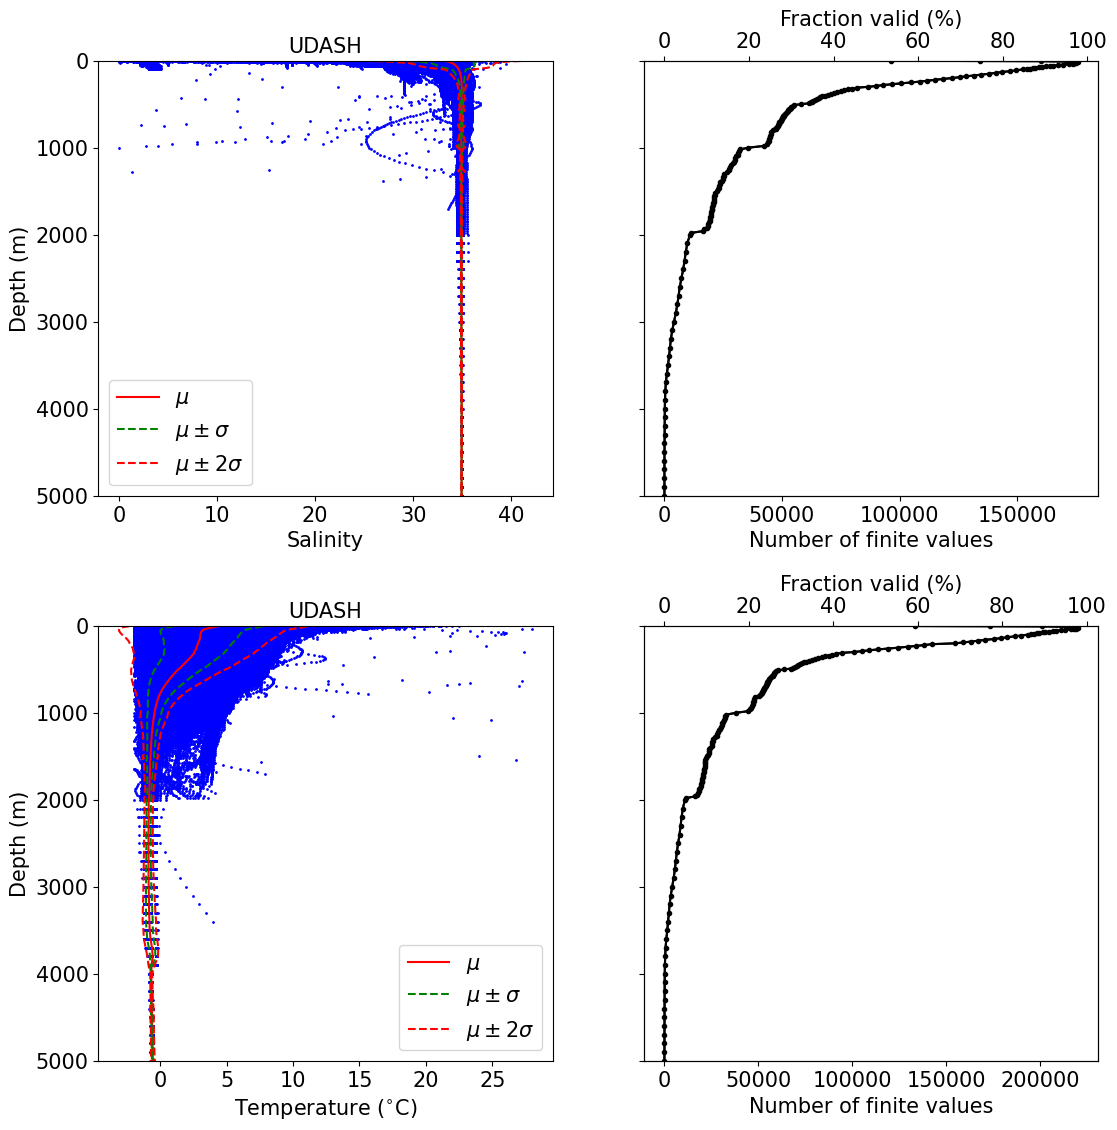

In [6]:
%%time
plot_vertical_distribution(ds_udash_psal,ds_udash_temp,source='UDASH')
plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_data_UDASH_vert_distribution.png',bbox_inches='tight',dpi=300)